# 🧵 Vezilka Dataset — Exploration & Quality Analysis

This notebook loads the **Macedonian ↔ Albanian** parallel corpus built from the Služben Vesnik (Official Gazette) and performs:

1. **Overview** — shape, columns, sample rows
2. **Length analysis** — word/char distributions per language
3. **Alignment method breakdown** — structural vs Gale-Church
4. **Confidence distribution** — quality scores
5. **Script validation** — Cyrillic (MK) vs Latin (SQ) check
6. **Known issues** — backtick encoding, hyphenation artefacts
7. **Source coverage** — which PDFs contributed the most pairs
8. **Sample pairs** — random inspection

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import re
from collections import Counter

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (12, 5)
plt.style.use('seaborn-v0_8-whitegrid')

TSV_PATH = 'data/export/vezilka_mk_sq.tsv'
print('✓ Libraries loaded')

✓ Libraries loaded


## 1. Load & Preview the Dataset

In [4]:
df = pd.read_csv(TSV_PATH, sep='\t', quoting=3)  # QUOTE_NONE to avoid issues with legal text
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(10)

Dataset shape: 100,897 rows × 6 columns
Columns: ['mk', 'sq', 'source', 'article_id', 'confidence', 'method']
Memory usage: 168.6 MB


,mk,sq,source,article_id,confidence,method
0,"увоз - извоз - Блатец - Виница , со земјоделск...",Republika e Maqedonisë hyri në borxh ndaj Bank...,5DEEADB1E363224EAF2DFA137F40E518,1,0.885,structural+gc_2-1
1,Со оваа одлука престанува правото на користење...,Afati për pagesës së kreditit prej nenit 1 të ...,5DEEADB1E363224EAF2DFA137F40E518,2,0.888,structural+gc_1-1
2,увоз - извоз - Блатец - Ви - ница .,Pas efikasitetit të kreditit do të pagohet pro...,5DEEADB1E363224EAF2DFA137F40E518,2,0.436,structural+gc_1-1
3,Договорот за замена на правото на сопственост ...,Shfrytëzuesi i fundit të kreditit është Drejto...,5DEEADB1E363224EAF2DFA137F40E518,3,0.899,structural+gc_1-1
4,"бр . 765/2002, од 11.03.2002 година , во регис...",Krediti prej nenit 1 të këtij ligji do ta pago...,5DEEADB1E363224EAF2DFA137F40E518,4,0.930,structural+gc_2-1
5,Субјектите наследници на Управата за Цивилна в...,Subjektet trashëgimtare e Drejtorisë së lundri...,5DEEADB1E363224EAF2DFA137F40E518,5,0.897,structural+gc_1-1
6,Министерството за финансии ќе наплатува од кра...,Ministria e financave do të paguajë nga shfryt...,5DEEADB1E363224EAF2DFA137F40E518,6,0.793,structural+gc_1-2
7,Доколку пристигнатите ануитети во роковите утв...,Derisa anuitetet e arritura në afatët të përca...,5DEEADB1E363224EAF2DFA137F40E518,7,0.819,structural+gc_1-1
8,"""Овој закон влегува во сила осмиот ден од дено...",Ky ligj hyn në fuqi nga dita e tetë prej shpal...,5DEEADB1E363224EAF2DFA137F40E518,8,0.817,structural+gc_1-1
9,(1) Деловните книги се водат за фискалната год...,"(1) Librat e punës udhëheqin për vitin fiskal,...",5DEEADB1E363224EAF2DFA137F40E518,9,0.779,structural+gc_1-1


In [5]:
# Basic info
print('--- Data Types ---')
print(df.dtypes)
print()
print('--- Null Counts ---')
print(df.isnull().sum())
print()
print('--- Unique Values ---')
for col in df.columns:
    print(f'  {col}: {df[col].nunique():,} unique')

--- Data Types ---
mk             object
sq             object
source         object
article_id     object
confidence    float64
method         object
dtype: object

--- Null Counts ---
mk            0
sq            0
source        0
article_id    0
confidence    0
method        0
dtype: int64

--- Unique Values ---
  mk: 94,784 unique
  sq: 94,118 unique
  source: 886 unique
  article_id: 629 unique
  confidence: 681 unique
  method: 4 unique


## 2. Sentence Length Analysis

In [6]:
# Compute word counts and char counts
df['mk_words'] = df['mk'].astype(str).apply(lambda x: len(x.split()))
df['sq_words'] = df['sq'].astype(str).apply(lambda x: len(x.split()))
df['mk_chars'] = df['mk'].astype(str).str.len()
df['sq_chars'] = df['sq'].astype(str).str.len()
df['word_ratio'] = df['mk_words'] / df['sq_words'].replace(0, np.nan)
df['char_ratio'] = df['mk_chars'] / df['sq_chars'].replace(0, np.nan)

print('=== Word Count Statistics ===')
print(df[['mk_words', 'sq_words']].describe().round(1))
print()
print('=== Character Count Statistics ===')
print(df[['mk_chars', 'sq_chars']].describe().round(1))

=== Word Count Statistics ===
       mk_words  sq_words
count  100897.0  100897.0
mean       65.2      65.7
std        98.9     100.2
min         1.0       1.0
25%        16.0      15.0
50%        35.0      35.0
75%        74.0      74.0
max      5632.0    5908.0

=== Character Count Statistics ===
       mk_chars  sq_chars
count  100897.0  100897.0
mean      386.6     410.6
std       586.6     624.3
min        15.0      15.0
25%        95.0      98.0
50%       209.0     221.0
75%       436.0     464.0
max     36261.0   38499.0


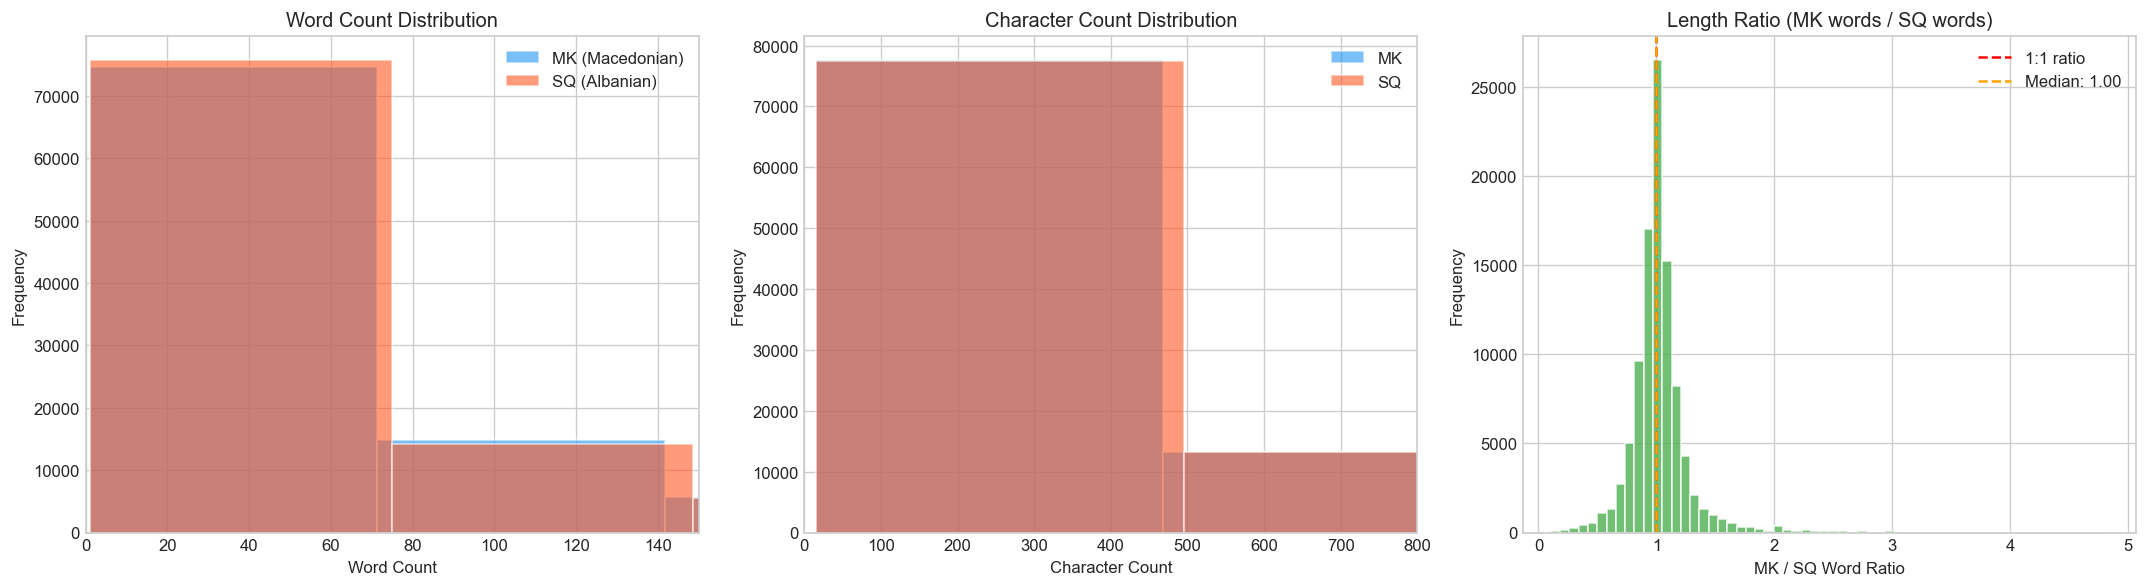

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Word count distributions
axes[0].hist(df['mk_words'], bins=80, alpha=0.6, label='MK (Macedonian)', color='#2196F3', edgecolor='white')
axes[0].hist(df['sq_words'], bins=80, alpha=0.6, label='SQ (Albanian)', color='#FF5722', edgecolor='white')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution')
axes[0].legend()
axes[0].set_xlim(0, 150)

# Character count distributions
axes[1].hist(df['mk_chars'], bins=80, alpha=0.6, label='MK', color='#2196F3', edgecolor='white')
axes[1].hist(df['sq_chars'], bins=80, alpha=0.6, label='SQ', color='#FF5722', edgecolor='white')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Character Count Distribution')
axes[1].legend()
axes[1].set_xlim(0, 800)

# MK/SQ word ratio
valid_ratio = df['word_ratio'].dropna()
valid_ratio = valid_ratio[(valid_ratio > 0.1) & (valid_ratio < 5)]
axes[2].hist(valid_ratio, bins=60, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[2].axvline(x=1.0, color='red', linestyle='--', label='1:1 ratio')
axes[2].axvline(x=valid_ratio.median(), color='orange', linestyle='--', label=f'Median: {valid_ratio.median():.2f}')
axes[2].set_xlabel('MK / SQ Word Ratio')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Length Ratio (MK words / SQ words)')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Alignment Method Breakdown

Total alignment methods: 4

method
structural+gc_1-1    82679
structural+gc_2-1    13484
structural+gc_1-2     3946
structural+gc_2-2      788



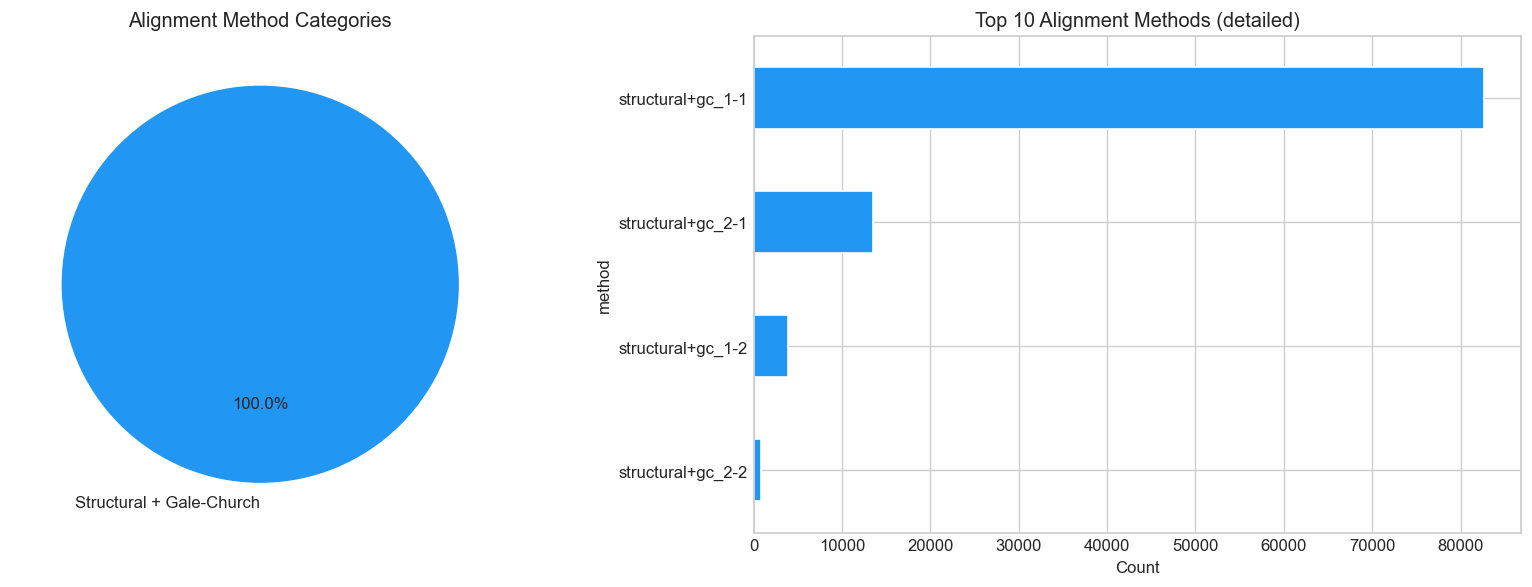

In [9]:
method_counts = df['method'].value_counts()
print(f'Total alignment methods: {len(method_counts)}')
print()
print(method_counts.to_string())
print()

# Simplify methods into categories
def categorize_method(m):
    m = str(m)
    if 'structural' in m and 'gc' in m:
        return 'Structural + Gale-Church'
    elif 'structural' in m:
        return 'Structural Only'
    elif 'gale_church' in m or 'gc' in m:
        return 'Gale-Church Only'
    else:
        return 'Other'

df['method_category'] = df['method'].apply(categorize_method)
cat_counts = df['method_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
cat_counts.plot.pie(ax=axes[0], autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_ylabel('')
axes[0].set_title('Alignment Method Categories')

method_counts.head(10).plot.barh(ax=axes[1], color='#2196F3', edgecolor='white')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 10 Alignment Methods (detailed)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Confidence Score Distribution

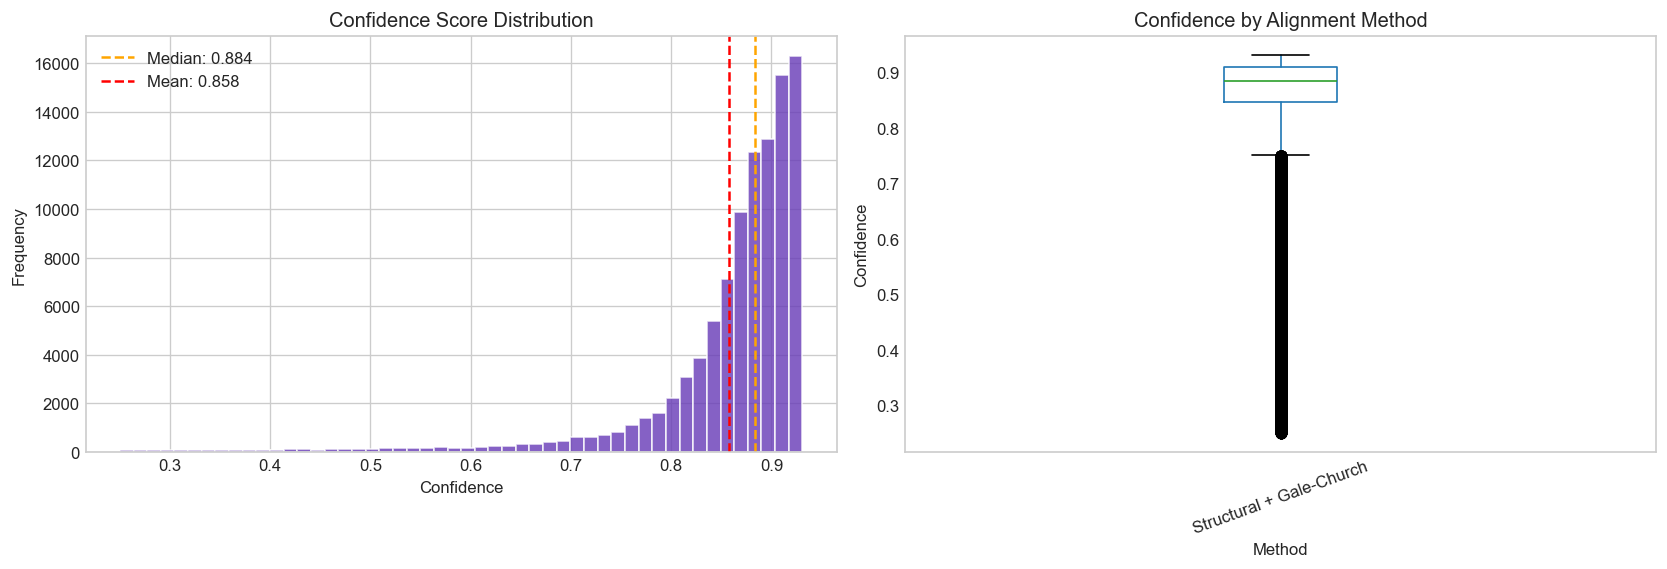

=== Confidence Statistics ===
count    100897.000
mean          0.858
std           0.091
min           0.250
25%           0.846
50%           0.884
75%           0.910
max           0.931
Name: confidence, dtype: float64

Pairs with confidence ≥ 0.8: 87,915 (87.1%)
Pairs with confidence ≥ 0.9: 35,813 (35.5%)
Pairs with confidence < 0.5: 1,737 (1.7%)


In [10]:
confidence = pd.to_numeric(df['confidence'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(confidence.dropna(), bins=50, color='#673AB7', edgecolor='white', alpha=0.8)
axes[0].axvline(x=confidence.median(), color='orange', linestyle='--', label=f'Median: {confidence.median():.3f}')
axes[0].axvline(x=confidence.mean(), color='red', linestyle='--', label=f'Mean: {confidence.mean():.3f}')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Confidence Score Distribution')
axes[0].legend()

# Confidence by method category
df['confidence_num'] = confidence
df.boxplot(column='confidence_num', by='method_category', ax=axes[1], grid=False)
axes[1].set_title('Confidence by Alignment Method')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Confidence')
plt.suptitle('')  # remove auto title
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('=== Confidence Statistics ===')
print(confidence.describe().round(3))
print(f'\nPairs with confidence ≥ 0.8: {(confidence >= 0.8).sum():,} ({(confidence >= 0.8).mean()*100:.1f}%)')
print(f'Pairs with confidence ≥ 0.9: {(confidence >= 0.9).sum():,} ({(confidence >= 0.9).mean()*100:.1f}%)')
print(f'Pairs with confidence < 0.5: {(confidence < 0.5).sum():,} ({(confidence < 0.5).mean()*100:.1f}%)')

## 5. Script Validation — Cyrillic (MK) vs Latin (SQ)

Script check on 5,000 sampled pairs:
  MK sentences with < 50% Cyrillic: 1 (0.0%)
  SQ sentences with < 50% Latin:    2 (0.0%)


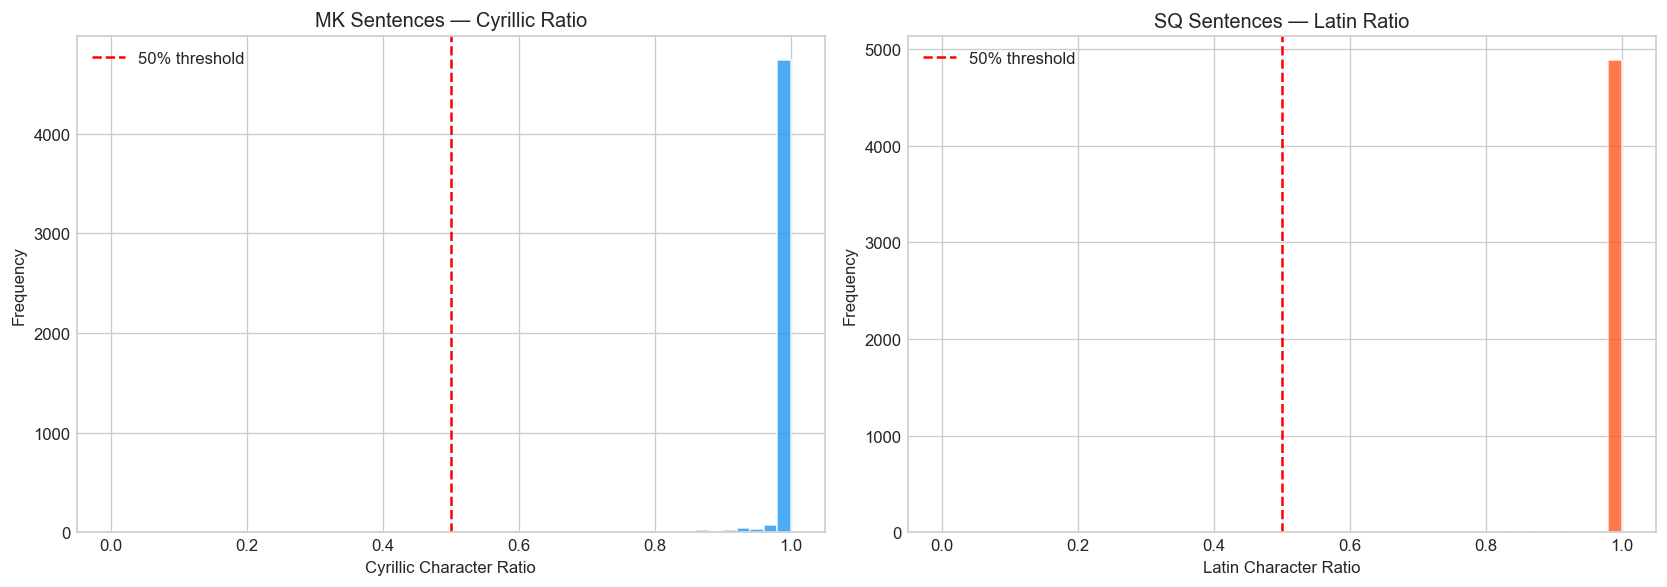

In [11]:
def cyrillic_ratio(text):
    """Fraction of alphabetic chars that are Cyrillic."""
    text = str(text)
    cyr = sum(1 for c in text if '\u0400' <= c <= '\u04FF')
    lat = sum(1 for c in text if c.isalpha() and not ('\u0400' <= c <= '\u04FF'))
    total = cyr + lat
    return cyr / total if total > 0 else 0.0

def latin_ratio(text):
    """Fraction of alphabetic chars that are Latin."""
    text = str(text)
    lat = sum(1 for c in text if ('A' <= c <= 'Z') or ('a' <= c <= 'z') or c in 'ëçËÇ')
    total = sum(1 for c in text if c.isalpha())
    return lat / total if total > 0 else 0.0

# Sample for speed (full dataset takes a while)
sample = df.sample(n=min(5000, len(df)), random_state=42)
sample['mk_cyr_ratio'] = sample['mk'].apply(cyrillic_ratio)
sample['sq_lat_ratio'] = sample['sq'].apply(latin_ratio)

mk_wrong = (sample['mk_cyr_ratio'] < 0.5).sum()
sq_wrong = (sample['sq_lat_ratio'] < 0.5).sum()

print(f'Script check on {len(sample):,} sampled pairs:')
print(f'  MK sentences with < 50% Cyrillic: {mk_wrong} ({mk_wrong/len(sample)*100:.1f}%)')
print(f'  SQ sentences with < 50% Latin:    {sq_wrong} ({sq_wrong/len(sample)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sample['mk_cyr_ratio'], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
axes[0].set_xlabel('Cyrillic Character Ratio')
axes[0].set_ylabel('Frequency')
axes[0].set_title('MK Sentences — Cyrillic Ratio')
axes[0].legend()

axes[1].hist(sample['sq_lat_ratio'], bins=50, color='#FF5722', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
axes[1].set_xlabel('Latin Character Ratio')
axes[1].set_ylabel('Frequency')
axes[1].set_title('SQ Sentences — Latin Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Known Issues Detection

In [12]:
# --- Issue 1: Backtick encoding (` should be ë in Albanian) ---
backtick_mask = df['sq'].astype(str).str.contains('`', regex=False)
backtick_count = backtick_mask.sum()

# --- Issue 2: Hyphenated line breaks in MK (e.g. "Ар - мијата" → "Армијата") ---
hyphen_break_mask = df['mk'].astype(str).str.contains(r'\w\s+-\s+\w', regex=True)
hyphen_count = hyphen_break_mask.sum()

# --- Issue 3: Hex hash leaking into text ---
hash_mask = df['mk'].astype(str).str.contains(r'[A-F0-9]{32}', regex=True) | \
            df['sq'].astype(str).str.contains(r'[A-F0-9]{32}', regex=True)
hash_count = hash_mask.sum()

# --- Issue 4: Very short pairs (possible noise) ---
very_short = ((df['mk_words'] < 3) | (df['sq_words'] < 3)).sum()

# --- Issue 5: Extreme length ratios ---
extreme_ratio = ((df['word_ratio'] < 0.3) | (df['word_ratio'] > 3.0)).sum()

print('=== Known Issues Summary ===')
print(f'  Backtick encoding (` → ë):       {backtick_count:>6,} pairs ({backtick_count/len(df)*100:.2f}%)')
print(f'  Hyphenated line breaks (MK):      {hyphen_count:>6,} pairs ({hyphen_count/len(df)*100:.2f}%)')
print(f'  Hex hash in text:                 {hash_count:>6,} pairs ({hash_count/len(df)*100:.2f}%)')
print(f'  Very short (< 3 words):           {very_short:>6,} pairs ({very_short/len(df)*100:.2f}%)')
print(f'  Extreme length ratio (>3x or <⅓): {extreme_ratio:>6,} pairs ({extreme_ratio/len(df)*100:.2f}%)')

=== Known Issues Summary ===
  Backtick encoding (` → ë):          219 pairs (0.22%)
  Hyphenated line breaks (MK):      39,039 pairs (38.69%)
  Hex hash in text:                      0 pairs (0.00%)
  Very short (< 3 words):            1,000 pairs (0.99%)
  Extreme length ratio (>3x or <⅓):    806 pairs (0.80%)


In [13]:
# Show examples of backtick issue
if backtick_count > 0:
    print('=== Backtick Encoding Examples (SQ side) ===')
    print('These ` characters should be ë (e-diaeresis) — a PDF font encoding issue.\n')
    examples = df[backtick_mask].head(3)
    for i, row in examples.iterrows():
        print(f'Row {i}:')
        print(f'  SQ: {str(row["sq"])[:200]}')
        fixed = str(row['sq']).replace('`', 'ë')
        print(f'  FIX: {fixed[:200]}')
        print()

=== Backtick Encoding Examples (SQ side) ===
These ` characters should be ë (e-diaeresis) — a PDF font encoding issue.

Row 58:
  SQ: Me k`t` ligj rregullohet statusi, t` drejtat, detyrat dhe p`rgjegjsit` e personave n` sh`rbim, n` Armat`n e Republik`s s` Maqedonis` ( n` tekstin e m`tutjesh`m : Armata), si dhe sistemi i rrogave dhe 
  FIX: Me këtë ligj rregullohet statusi, të drejtat, detyrat dhe përgjegjsitë e personave në shërbim, në Armatën e Republikës së Maqedonisë ( në tekstin e mëtutjeshëm : Armata), si dhe sistemi i rrogave dhe 

Row 59:
  SQ: N`n sh`rbim n` Armat` konsiderohet kryerje e detyrave ushtarake n` Armat`.
  FIX: Nën shërbim në Armatë konsiderohet kryerje e detyrave ushtarake në Armatë.

Row 60:
  SQ: Si sh`rbim n` Armat` konsiderohet edhe kryerje e detyrave tjera n` Ministrin` p`r mbrojtje, Akademin` ushtarake, organe tjera t` pushtetit shtet`ror, shoqata tregtare, nd`rmarrje publike, isntitucione
  FIX: Si shërbim në Armatë konsiderohet edhe kryerje e detyrave tjer

## 7. Source PDF Coverage

Total unique source PDFs: 886
Mean pairs per source:    113.9
Median pairs per source:  61.0
Max pairs from 1 source:  1,732 (0B7D0CE4EBCBAB4AAA21D9D1D96797D8)
Sources with only 1 pair: 2


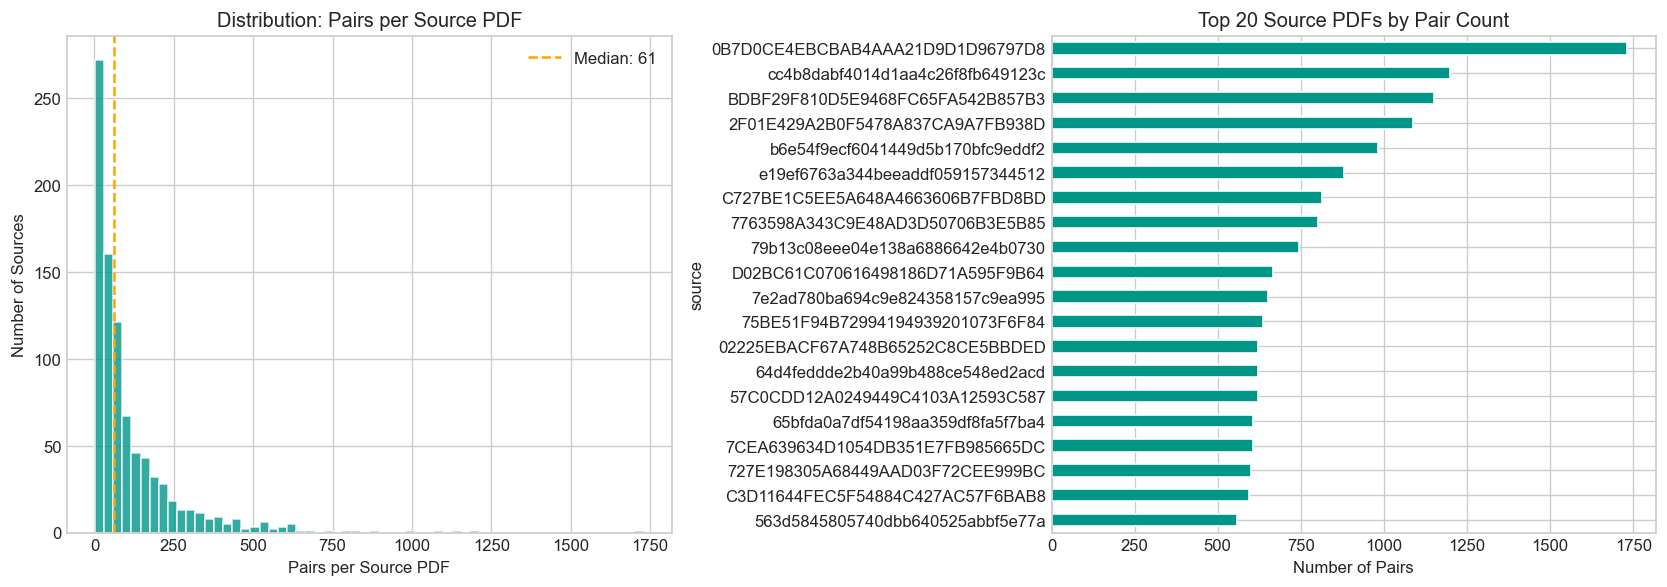

In [14]:
source_counts = df['source'].value_counts()

print(f'Total unique source PDFs: {len(source_counts):,}')
print(f'Mean pairs per source:    {source_counts.mean():.1f}')
print(f'Median pairs per source:  {source_counts.median():.1f}')
print(f'Max pairs from 1 source:  {source_counts.max():,} ({source_counts.idxmax()})')
print(f'Sources with only 1 pair: {(source_counts == 1).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of pairs per source
axes[0].hist(source_counts.values, bins=60, color='#009688', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Pairs per Source PDF')
axes[0].set_ylabel('Number of Sources')
axes[0].set_title('Distribution: Pairs per Source PDF')
axes[0].axvline(x=source_counts.median(), color='orange', linestyle='--', label=f'Median: {source_counts.median():.0f}')
axes[0].legend()

# Top 20 sources
top20 = source_counts.head(20)
top20.plot.barh(ax=axes[1], color='#009688', edgecolor='white')
axes[1].set_xlabel('Number of Pairs')
axes[1].set_title('Top 20 Source PDFs by Pair Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Article ID Analysis

In [15]:
article_counts = df['article_id'].value_counts()

print(f'Unique article IDs: {len(article_counts):,}')
print(f'\nTop 15 article IDs:')
print(article_counts.head(15).to_string())

# How many are Gale-Church fallback vs numbered articles
gc_articles = (df['article_id'].astype(str) == 'gc').sum()
numbered = df['article_id'].astype(str).str.match(r'^\d+$').sum()
other_ids = len(df) - gc_articles - numbered

print(f'\nArticle ID breakdown:')
print(f'  Numbered articles (1, 2, ...): {numbered:,} ({numbered/len(df)*100:.1f}%)')
print(f'  Gale-Church fallback (gc):     {gc_articles:,} ({gc_articles/len(df)*100:.1f}%)')
print(f'  Other:                         {other_ids:,} ({other_ids/len(df)*100:.1f}%)')

Unique article IDs: 629

Top 15 article IDs:
article_id
9     3960
8     3543
0     3287
2     2270
3     2201
4     1991
5     1734
10    1388
12    1368
6     1328
16    1266
7     1137
14    1090
11    1064
15    1007

Article ID breakdown:
  Numbered articles (1, 2, ...): 100,896 (100.0%)
  Gale-Church fallback (gc):     0 (0.0%)
  Other:                         1 (0.0%)


## 9. Random Sample Inspection

In [16]:
# Show 10 random high-confidence pairs for human inspection
high_conf = df[pd.to_numeric(df['confidence'], errors='coerce') >= 0.85]
sample_pairs = high_conf.sample(n=min(10, len(high_conf)), random_state=123)

print(f'=== 10 Random High-Confidence Pairs (≥ 0.85) ===')
print(f'    (from {len(high_conf):,} high-confidence pairs)\n')

for idx, (_, row) in enumerate(sample_pairs.iterrows(), 1):
    print(f'[{idx}] MK: {str(row["mk"])[:120]}')
    print(f'    SQ: {str(row["sq"])[:120]}')
    print(f'    confidence={row["confidence"]}  method={row["method"]}  article={row["article_id"]}')
    print()

=== 10 Random High-Confidence Pairs (≥ 0.85) ===
    (from 74,054 high-confidence pairs)

[1] MK: „Ин- дустриска – 1“ бр.31, бр.
    SQ: Дел 18 - METAMIZOLE SODIUM 500mg таб- 38.
    confidence=0.883  method=structural+gc_1-1  article=8

[2] MK: Обврска за доставување на Годишен извеш- тај за работењето Носителот на лиценцата е должен до Регулаторната комисија за 
    SQ: Detyrimi për dërgimin e Raportit Vjetor të Punës Bartësi i licencës është i detyruar që, deri te Komisioni Rregullator i
    confidence=0.876  method=structural+gc_1-1  article=16

[3] MK: „Браќа Минкови“ бр.41, бр.
    SQ: ДЕЛ 6 N05BA01 Diazepam 7.
    confidence=0.905  method=structural+gc_1-1  article=8

[4] MK: Престанување на важноста на договорот за вработување поради смрт на работникот , односно работодавачот ( физичко лице )
    SQ: Shuarja e vlefshmërisë së marrëveshjes për punësim për shkak të vdekjes së punëtorit përkatësisht punëdhënësit (personit
    confidence=0.918  method=structural+gc_1-1  article=64


## 10. Dataset Summary Dashboard

In [17]:
conf_numeric = pd.to_numeric(df['confidence'], errors='coerce')

print('╔══════════════════════════════════════════════════════════════╗')
print('║           VEZILKA CORPUS — DATASET SUMMARY                 ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Total sentence pairs:     {len(df):>8,}                        ║')
print(f'║  Unique source PDFs:       {df["source"].nunique():>8,}                        ║')
print(f'║  Unique article IDs:       {df["article_id"].nunique():>8,}                        ║')
print(f'║  Alignment methods:        {df["method"].nunique():>8,}                        ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Avg MK words/sentence:    {df["mk_words"].mean():>8.1f}                        ║')
print(f'║  Avg SQ words/sentence:    {df["sq_words"].mean():>8.1f}                        ║')
print(f'║  Median confidence:        {conf_numeric.median():>8.3f}                        ║')
print(f'║  High-confidence (≥0.85):  {(conf_numeric >= 0.85).sum():>8,}  ({(conf_numeric >= 0.85).mean()*100:.1f}%)              ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(f'║  Backtick encoding issues: {backtick_count:>8,}  ({backtick_count/len(df)*100:.2f}%)              ║')
print(f'║  Hyphen-break artefacts:   {hyphen_count:>8,}  ({hyphen_count/len(df)*100:.2f}%)              ║')
print(f'║  Total MK words:          {df["mk_words"].sum():>10,}                      ║')
print(f'║  Total SQ words:          {df["sq_words"].sum():>10,}                      ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║           VEZILKA CORPUS — DATASET SUMMARY                 ║
╠══════════════════════════════════════════════════════════════╣
║  Total sentence pairs:      100,897                        ║
║  Unique source PDFs:            886                        ║
║  Unique article IDs:            629                        ║
║  Alignment methods:               4                        ║
╠══════════════════════════════════════════════════════════════╣
║  Avg MK words/sentence:        65.2                        ║
║  Avg SQ words/sentence:        65.7                        ║
║  Median confidence:           0.884                        ║
║  High-confidence (≥0.85):    74,054  (73.4%)              ║
╠══════════════════════════════════════════════════════════════╣
║  Backtick encoding issues:      219  (0.22%)              ║
║  Hyphen-break artefacts:     39,039  (38.69%)              ║
║  Total MK words:           6,582,051           